<a href="https://colab.research.google.com/github/4zmyyy/AMPG-banten-database/blob/main/AMPG%20DATABASE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv('regional_chapters.csv')
df_prov = pd.read_csv('provincial_board.csv')
print(df[['region', 'total_sk', 'filled', 'completion_rate_pct', 'rakorda_status']].to_string(index=False))

                region  total_sk  filled  completion_rate_pct rakorda_status
        Kota Tangerang        41      54                131.7          Sudah
Kota Tangerang Selatan       136     123                 96.3          Belum
           Kota Serang        64      58                 90.6          Sudah
   Kabupaten Tangerang        65      24                 36.9          Belum
  Kabupaten Pandeglang        43      33                 76.7          Belum
      Kabupaten Serang        21      21                100.0          Belum
       Kabupaten Lebak        43      47                109.3          Belum
          Kota Cilegon        70      15                 21.4          Belum


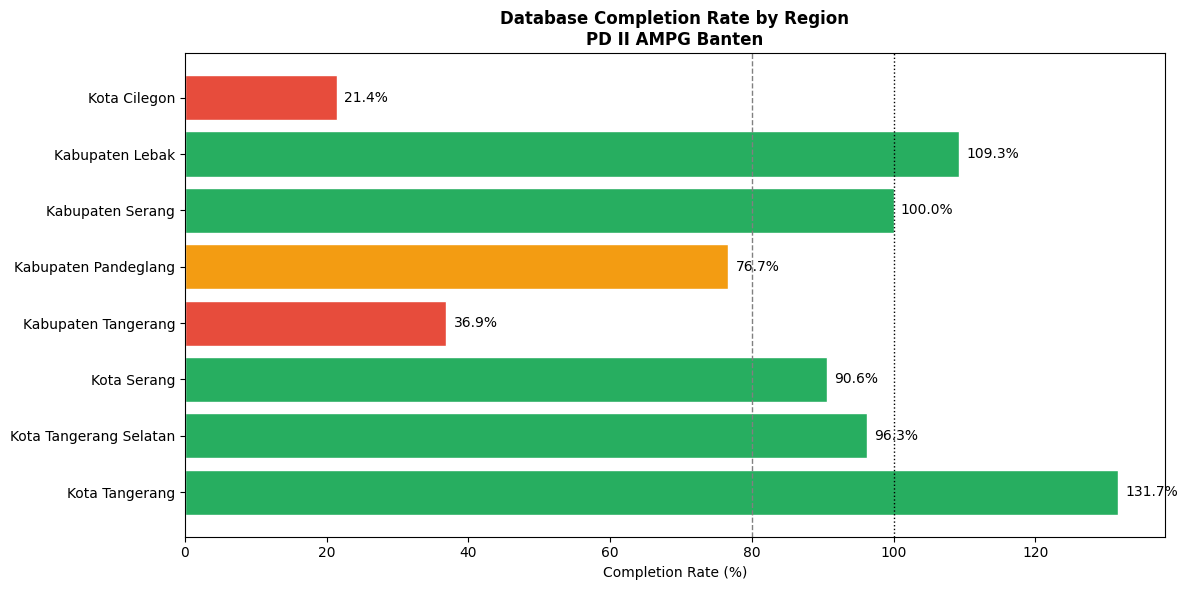

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if r < 50 else '#f39c12' if r < 80 else '#27ae60'
          for r in df['completion_rate_pct']]
bars = ax.barh(df['region'], df['completion_rate_pct'], color=colors, edgecolor='white')
ax.axvline(x=80, color='gray', linestyle='--', linewidth=1)
ax.axvline(x=100, color='black', linestyle=':', linewidth=1)
for bar, val in zip(bars, df['completion_rate_pct']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Completion Rate (%)')
ax.set_title('Database Completion Rate by Region\nPD II AMPG Banten', fontweight='bold')
plt.tight_layout()
plt.savefig('completion_rate.png', dpi=150)
plt.show()

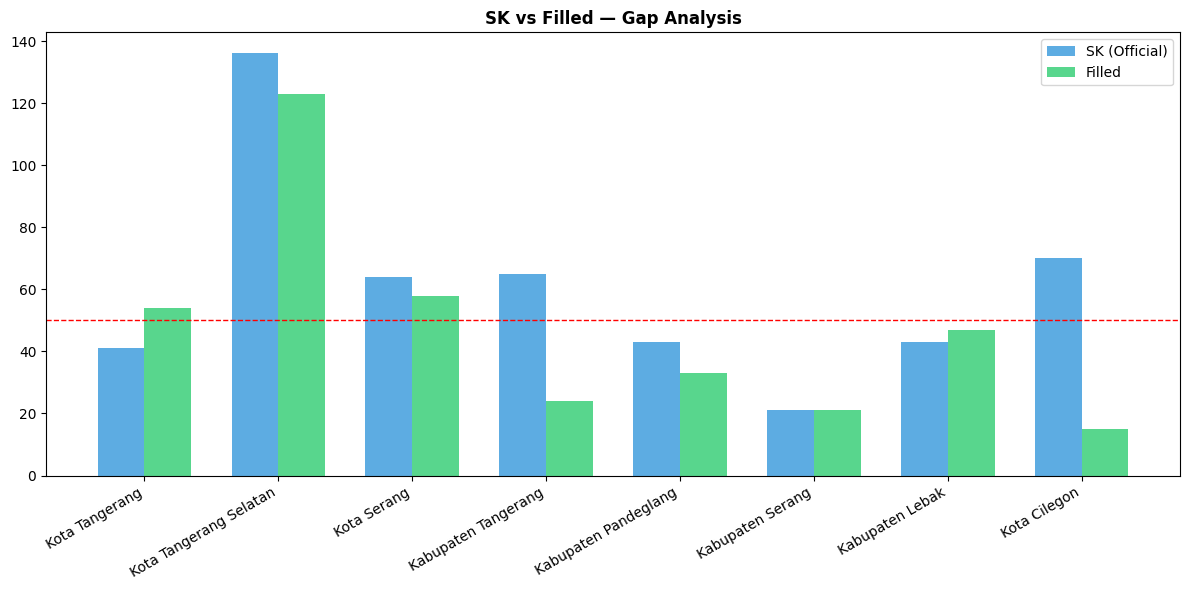

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df))
width = 0.35
ax.bar(x - width/2, df['total_sk'], width, label='SK (Official)', color='#3498db', alpha=0.8)
ax.bar(x + width/2, df['filled'], width, label='Filled', color='#2ecc71', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df['region'], rotation=30, ha='right', fontsize=10)
ax.axhline(y=50, color='red', linestyle='--', linewidth=1)
ax.set_title('SK vs Filled — Gap Analysis', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('gap_analysis.png', dpi=150)
plt.show()